# Virtual Try-On (VTO) MVP - Backend Pipeline (Phase 1)

This notebook implements the core backend logic for a Virtual Try-On system using the **modern MediaPipe Tasks API**, which is the most stable version for macOS arm64 (M1/M2/M3).

### 🧩 Modules
1. **User Input Module**: Load images and sizing measurements.
2. **Garment Processing Module**: Segment clothing.
3. **Body Estimation Module**: Detect 33 body keypoints + segmentation map using **Tasks API**.
4. **Try-On Engine**: Warp garment using pose and segmentation data.
5. **Rendering & Output Module**: Final composite and result saving.

### 🛠️ Step 1: Dependencies & Model Downloader
We need to download the official MediaPipe model files (`.task`) for the new API to work.

In [1]:
# Install dependencies and ensure NumPy 1.x (MediaPipe requirement)
%pip install -U "numpy<2" mediapipe opencv-python matplotlib python-dotenv pillow scipy requests

  Using cached opencv_python-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
  Using cached opencv_python-4.13.0.90-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
  Using cached opencv_python-4.12.0.88-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import requests
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sys
from dotenv import load_dotenv

print("--- Backend Initialization ---")

# 1. Setup Storage and Model Paths
load_dotenv()
STORAGE_PATH = os.getenv('STORAGE_PATH', './storage')
MODEL_PATH = os.path.join(STORAGE_PATH, 'models')
os.makedirs(MODEL_PATH, exist_ok=True)

POSE_MODEL_URL = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task"
SEG_MODEL_URL = "https://storage.googleapis.com/mediapipe-models/image_segmenter/selfie_segmenter/float16/1/selfie_segmenter.task"

POSE_MODEL_FILE = os.path.join(MODEL_PATH, "pose_landmarker.task")
SEG_MODEL_FILE = os.path.join(MODEL_PATH, "selfie_segmenter.task")

def download_model(url, save_path):
    if not os.path.exists(save_path):
        print(f"Downloading model to {save_path}... (this may take a minute)")
        r = requests.get(url, stream=True)
        with open(save_path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
        print("Download complete.")

download_model(POSE_MODEL_URL, POSE_MODEL_FILE)
download_model(SEG_MODEL_URL, SEG_MODEL_FILE)

print(f"Environment Ready. NumPy: {np.__version__}")

--- Backend Initialization ---
Download complete.
Download complete.
Environment Ready. NumPy: 1.26.4


## 2️⃣ Body Estimation Module (Modern Tasks API)
This replaces the legacy `solutions` API with the new, robust `tasks` API.

In [3]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

def get_pose_landmarks(image_rgb):
    """Detects pose landmarks using Tasks API."""
    base_options = python.BaseOptions(model_asset_path=POSE_MODEL_FILE)
    options = vision.PoseLandmarkerOptions(
        base_options=base_options,
        output_segmentation_masks=True)
    
    with vision.PoseLandmarker.create_from_options(options) as landmarker:
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
        result = landmarker.detect(mp_image)
        if not result.pose_landmarks: return None, None
        return result.pose_landmarks[0], result.segmentation_masks[0].numpy_view()

def extract_anchor_points(landmarks, h, w):
    """Extract essential points for warping."""
    return {
        'ls': (int(landmarks[11].x * w), int(landmarks[11].y * h)),
        'rs': (int(landmarks[12].x * w), int(landmarks[12].y * h)),
        'lh': (int(landmarks[23].x * w), int(landmarks[23].y * h)),
        'rh': (int(landmarks[24].x * w), int(landmarks[24].y * h))
    }

## 3️⃣ Garment Processing & Try-On Pipeline

In [4]:
def process_garment(garment_rgb):
    gray = cv2.cvtColor(garment_rgb, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 248, 255, cv2.THRESH_BINARY_INV)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((5,5), np.uint8))
    return garment_rgb, mask

def run_vto_pipeline(person_path, garment_path):
    try:
        # 1. Load
        person = cv2.imread(person_path)
        cloth = cv2.imread(garment_path)
        if person is None or cloth is None: return "Error: Image not found.", None
        
        person_rgb = cv2.cvtColor(person, cv2.COLOR_BGR2RGB)
        cloth_rgb = cv2.cvtColor(cloth, cv2.COLOR_BGR2RGB)
        
        # 2. Process Garment
        g_rgb, g_mask = process_garment(cloth_rgb)
        
        # 3. Estimate Human
        landmarks, human_mask = get_pose_landmarks(person_rgb)
        if landmarks is None: return "Error: MediaPipe could not detect person.", None
        
        # 4. Warp Garment
        ph, pw, _ = person_rgb.shape
        pts = extract_anchor_points(landmarks, ph, pw)
        
        src_pts = np.float32([[0,0], [cloth.shape[1], 0], [0, cloth.shape[0]], [cloth.shape[1], cloth.shape[0]]])
        dst_pts = np.float32([pts['rs'], pts['ls'], pts['rh'], pts['lh']])
        
        matrix = cv2.getPerspectiveTransform(src_pts, dst_pts)
        w_cloth = cv2.warpPerspective(g_rgb, matrix, (pw, ph))
        w_mask = cv2.warpPerspective(g_mask, matrix, (pw, ph))
        
        # 5. Composite (Rendering)
        alpha = w_mask.astype(float) / 255.0
        alpha = cv2.merge([alpha, alpha, alpha])
        
        res = (person_rgb.astype(float) * (1.0 - alpha)) + (w_cloth.astype(float) * alpha)
        res = res.astype(np.uint8)
        
        return res, person_rgb
    except Exception as e:
        return f"Pipeline failed: {e}", None

## 🚀 Run VTO MVP Demo

I0000 00:00:1773016945.831203  203536 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 88.1), renderer: Apple M3
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1773016945.932237  203539 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773016946.021233  203540 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773016946.137340  203542 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


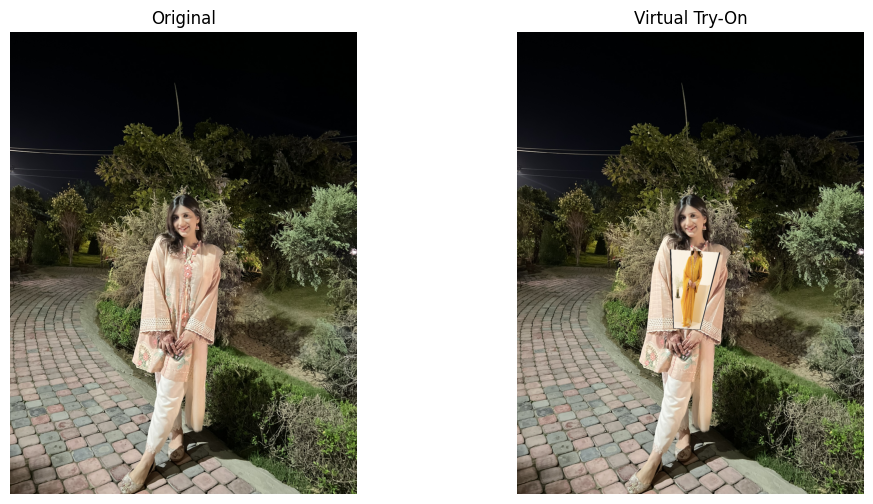

--- Result saved to: ./storage/vto_output.jpg ---


In [5]:
# File Names from your directory
person_file = 'D615854E-A045-42E3-82DA-E91D66DC6C14_1_102_o.jpeg'
cloth_file = '600C2583-F83C-4846-A70E-655A8979768C_1_201_a.jpeg'

if os.path.exists(person_file) and os.path.exists(cloth_file):
    result, original = run_vto_pipeline(person_file, cloth_file)
    
    if isinstance(result, np.ndarray):
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1); plt.imshow(original); plt.title('Original'); plt.axis('off')
        plt.subplot(1, 2, 2); plt.imshow(result); plt.title('Virtual Try-On'); plt.axis('off')
        plt.show()
        
        # Save Result
        save_path = os.path.join(STORAGE_PATH, 'vto_output.jpg')
        cv2.imwrite(save_path, cv2.cvtColor(result, cv2.COLOR_RGB2BGR))
        print(f"--- Result saved to: {save_path} ---")
    else:
        print(result)
else:
    print("Images not found. Ensure the filenames match exactly.")

In [ ]:
# tryon.py
from PIL import Image
from src.pipeline import FASHNPipeline

# Load pipeline (CPU mode)
pipe = FASHNPipeline.from_pretrained("./weights")
pipe.to("cpu")

# Load your images
person_image = Image.open("person.jpg")
garment_image = Image.open("garment.jpg")

# Run try-on
result = pipe(
    model_image=person_image,
    garment_image=garment_image,
    category="tops",          # "tops" / "bottoms" / "one-pieces"
    num_inference_steps=20,   # Lower = faster on CPU (try 10–20)
)

result.images[0].save("output.jpg")
print("Done! Saved to output.jpg")